# Magnet Ramp Analysis

In [113]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
import glob
import re
import matplotlib.ticker as ticker
from scipy import stats
import qcodes as qc
import sys
from scipy import stats
import scipy.signal as peak
import matplotlib.colors as colors
import scipy.stats as scs

# Append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")

# Import functions!!
import qil_helpers.Angela.angelaHelpers as ang 
import qil_helpers.Fergus.my_functions as mf

## Functions

In [90]:
# PIEZO COLLECT BY FIELD
def collect_piezo_by_field(flds_directory, sites, aom, num_bins, ylim):
    """
    Returns:
        all_freqsVpeaks[field][site] = DataFrame
    """
    all_freqsVpeaks = {}
    timeLimit = None

    for fld_directory in flds_directory:
        field_key = os.path.basename(os.path.normpath(fld_directory))
        all_freqsVpeaks[field_key] = {}
        sites_directory = sorted(os.listdir(fld_directory))
        for site in sites_directory:
            site_key = os.path.basename(os.path.normpath(site))
            site_path = os.path.join(fld_directory, site)
            files = sorted(
                [f for f in os.listdir(site_path) if f.endswith(".csv")],
                key=lambda f: float(f.split("_")[2])) # assumes freq in filename
            freqs = []
            peaks = []
            pVs = []
            is_saturated = []

            for file in files:
                file_path = os.path.join(site_path, file)
                file_read = np.loadtxt(file_path, delimiter=",")
                times, data = file_read[0], file_read[1]

                # Extract metadata from filename
                parts = file.split("_")
                freq = float(parts[2]) + aom * 1e3   # MHz
                pV = float(parts[-2])
                counts = np.sum(data[:num_bins + 1])
                maxLim = ylim[1]
                if timeLimit is None:
                    timeLimit = float(times[num_bins])
                freqs.append(freq)
                peaks.append(counts)
                pVs.append(pV)
                is_saturated.append(counts > maxLim)

            # Build DataFrame
            df = pd.DataFrame({
                "Frequencies (MHz)": freqs,
                f"Counts over {timeLimit*1e3} ms": peaks,
                "Piezo Voltage (V)": pVs,
                "Saturated": is_saturated})
            df = df.sort_values("Frequencies (MHz)").reset_index(drop=True)

            # Store in hierarchy
            if site_key not in all_freqsVpeaks:
                all_freqsVpeaks[site_key] = {}
            all_freqsVpeaks[site_key][field_key] = df

    return all_freqsVpeaks, timeLimit

# MOTOR COLLECT BY FIELD
def collect_motor_by_field(flds_directory, sites, aom, which_bins, ylim):
    """
    Returns:
        all_freqsVpeaks[field][site] = DataFrame
    """
    all_freqsVpeaks = {}
    timeLimit = None

    for fld_directory in flds_directory:
        field_key = os.path.basename(os.path.normpath(fld_directory))
        all_freqsVpeaks[field_key] = {}

        # Get site folders
        sites_directory = sorted(os.listdir(fld_directory))

        for site in sites_directory:
            site_key = os.path.basename(os.path.normpath(site))
            site_path = os.path.join(fld_directory, site)
            files = sorted(
                [f for f in os.listdir(site_path) if f.endswith(".csv")],
                key=lambda f: float(f.split("_")[2])  # assumes freq in filename
            )

            freqs = []
            peaks = []
            is_saturated = []

            for file in files:
                file_path = os.path.join(site_path, file)
                file_read = np.loadtxt(file_path, delimiter=",")
                times, data = file_read[0], file_read[1]

                # Extract metadata from filename
                parts = file.split("_")
                freq = float(parts[2]) + aom * 1e3   # MHz
                counts = np.sum(data[which_bins[0]:which_bins[1]])
                maxLim = ylim[1]

                if timeLimit is None:
                    timeLimit = [float(times[which_bins[0]]), float(times[which_bins[1]])]

                freqs.append(freq)
                peaks.append(counts)
                is_saturated.append(counts > maxLim)

            # Build DataFrame
            df = pd.DataFrame({
                "Frequencies (MHz)": freqs,
                f"Counts": peaks,
                "Saturated": is_saturated})
            df = df.sort_values("Frequencies (MHz)").reset_index(drop=True)

            # Store in hierarchy
            if site_key not in all_freqsVpeaks:
                all_freqsVpeaks[site_key] = {}
            all_freqsVpeaks[site_key][field_key] = df

    return all_freqsVpeaks, timeLimit

def process_colourmap(site_data):
    """
    Input:
        site_data[field] = DataFrame

    Returns:
        counts_matrix (freq x field),
        fields (sorted),
        freqs,
        centre_freqs
    """

    # Sort fields numerically
    fields = np.array([float(k.replace("A", "")) for k in site_data.keys()])
    sorted_idx = np.argsort(fields)
    fields = fields[sorted_idx]
    sorted_keys = np.array(list(site_data.keys()))[sorted_idx]

    # Assume same frequency axis across fields
    freqs = site_data[sorted_keys[0]]["Frequencies (MHz)"].values
    counts_matrix = np.zeros((len(freqs), len(fields)))
    freqs_matrix = np.zeros((len(freqs), len(fields)))

    for i, key in enumerate(sorted_keys):
        df = site_data[key]
        counts_matrix[:, i] = df.iloc[:, 1].values
        freqs_matrix[:, i] = df["Frequencies (MHz)"].values

    return counts_matrix, freqs_matrix, fields, freqs

### FUNCTIONALISE ###
# # Plot average centre frequency for each piezo scan at field
# fig, ax = plt.subplots(1, 2, figsize = (10, 3), sharey = False)
# centre_freqs = np.median(freqs_matrix, axis = 0)
# detuned_freqs = (centre_freqs - site[0]*1e6)
# bin_width = abs(freqs_matrix[:, 50][-1] - freqs_matrix[:, 50][0])/len(freqs_matrix[:, 50])
# detuned_bins = np.floor(detuned_freqs/bin_width) # Round detuning to number of bins in frequency
# ax1 = ax[0]
# fields = currents * mango_cc
# ax1.plot(fields, detuned_bins)
# ax1.set_xlabel('Current Step (A)')
# ax1.set_ylabel('Centre Detuning (# Bins)')
# plt.tight_layout()

# # Plot centre frequency drift
# ax2 = ax[1]
# ax2.pcolormesh(fields, freqs/1e3, freqs_matrix, cmap = 'viridis')
# ax2.set_xlabel('Current Step (A)')
# ax2.set_ylabel('Step Frequency (GHz)')
# plt.tight_layout()
# plt.show() 

# # Account for piezo drift by shifting columns
# shift_spectrum = np.zeros_like(counts_matrix)
# n_rows, n_cols = shift_spectrum.shape
# for j in range(n_cols):
#     shift = int(detuned_bins[j])
#     col = counts_matrix[:, j]
#     if shift > 0:  # shift down
#         shift_spectrum[shift:, j] = col[:-shift]
#     elif shift < 0:  # shift up
#         shift_spectrum[:shift, j] = col[-shift:]
#     else:
#         shift_spectrum[:, j] = col
# counts_matrix = shift_spectrum
### FUNCTIONALISE ###

# Peak picking
save_path = "data processed\peak picking data"
os.makedirs(save_path, exist_ok=True)
selected_points = []
# clicks = []

def onclick(event, freqs, counts, field):
    if event.xdata and event.ydata:
        # Find the nearest point to the clicked x-coordinate (frequency)
        freq_clicked = event.xdata
        count_clicked = np.interp(freq_clicked, freqs, counts)
        selected_points.append((freq_clicked, count_clicked, field))
        plt.scatter(freq_clicked, count_clicked, color='red')
        plt.draw()
        # clicks.append((freq_clicked, count_clicked, field))

def save_selected_points(description='peak'):
    peak_name = input("Enter the peak name: ")
    timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    filename = f"{timestamp}_{description}_{peak_name}.csv"
    df = pd.DataFrame(selected_points, columns=['Frequency (GHz)','Signal',  'B Field (mT)', ])
    file_path = os.path.join(save_path, filename)
    df.to_csv(file_path, index=False)
    print(f'Saved selected points to {filename}')

def find_zeeman_peaks_with_click(counts_matrix, freqs_matrix, fields, desc):
    global counts, freqs, field
    # Prompt user for number of bin steps
    try:
        bin_step = int(input("Enter number of bins per step (e.g., 10): "))
        if bin_step <= 0:
            raise ValueError("Field step must be a positive integer.")
    except ValueError:
        print("Invalid input. Using default field step of 5.")
        bin_step = 5

    # Plot individual spectra based on user-defined bin steps
    for i in range(len(counts_matrix[0, :]) - 1, -1, -bin_step):
        counts = counts_matrix[:, i] # select column from counts matrix
        freqs = freqs_matrix[:, i] # select column from freqs matrix
        field = fields[i]
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.scatter(freqs, counts, label=f'B Field: {field:.1f} mT')
        ax.plot(freqs, counts, alpha = 0.5)
        ax.set_xlabel('Frequency (GHz)')
        ax.set_ylabel('Counts')
        ax.set_xticks
        ax.set_title(f'Spectrum at {field:.1f} mT')
        ax.grid(True)
        ax.legend()
        cid = fig.canvas.mpl_connect('button_press_event',
            lambda event, f = freqs, c = counts, B = field: onclick(event, f, c, B))
        plt.show(block=False)
        print("Click on the graph to select peaks. Press any key to move to the next plot.")
        plt.waitforbuttonpress()
        plt.close()
    save_selected_points(desc)

# Import Data

In [29]:
# Import data 
mango_cc = 24.6 # mT/A

caf_0216 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-16\caf\mango field ramp\run_1\*'))
caf_0220_run3 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-20\caf\mango field ramp\run_3\*'))
caf_0220_run6 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-20\caf\mango field ramp\run_6\*'))

sic_0318 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-03-18\sic\mango field ramp\*\*'))
sic_0326 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-03-26\sic\mango field ramp\*\*'))

# CaF2

In [31]:
## Default: [frequency (THz), wavelength (nm), label]
CaF_trn = {
    'A_Z1Y1': [197.05, 1521.296, r'A: $Z_1 \to Y_1$'],
    'G1_Z1Y1': [197.4686, 1518.070, r'G1: $Z_1 \to Y_1$'],
    'A_Z1Y2': [197.913, 1514.664, r'A: $Z_1 \to Y_2$'],
    'G1_Z1Y2': [198.2567, 1512.037, r'G1: $Z_1 \to Y_2$'],
    'B_Z1Y1': [198.76215, 1508.195, r'B: $Z_1 \to Y_1$'],
    'Cube_Z1Y1': [198.927, 1506.945, r'Cubic: $Z_1 \to Y_1$'],
    'Cube_Z1Y2':[199.242, 1504.563, r'Cubic: $Z_1 \to Y_2$']
    }

In [6]:
CaF_all_freqsVpeaks, CaF_timeLimit = collect_piezo_by_field(caf_0220_run6, 
                                          sites = CaF_trn, 
                                          aom = 0.380, 
                                          num_bins = 40, 
                                          ylim = [0, 4e3])

In [7]:
# %matplotlib inline
%matplotlib 
plt.ion()
countLims = [2e3, 2e3, 3e4, 9.2e2, 7e2, 1.8e3, 7.6e2]
# cmap = np.random.choice(colormaps)

for i, site in enumerate(CaF_trn):
    selected_points.clear()
    # ID each site 
    site = CaF_trn[f'{site}']
    wavelength = site[1]
    siteData = CaF_all_freqsVpeaks[f'{wavelength:.3f}']
    print(f'Site {site[2]} at {site[0]} THz')

    # Process to extract data
    counts_matrix, freqs_matrix, currents, freqs = process_colourmap(siteData)
    fields = currents * mango_cc

    # Filter for outliers
    counts_matrix[counts_matrix > countLims[i]] = 0

    # Plot average centre frequency for each piezo scan at field
    centre_freqs = np.median(freqs_matrix, axis = 0)
    detuned_freqs = (centre_freqs - site[0]*1e6)
    bin_width = abs(freqs_matrix[:, -1][-1] - freqs_matrix[:, -1][0])/len(freqs_matrix[:, -1])
    detuned_bins = np.floor(detuned_freqs/bin_width) # Round detuning to number of bins in frequency

    # Account for piezo drift by shifting columns
    shift_spectrum = np.zeros_like(counts_matrix)
    n_rows, n_cols = shift_spectrum.shape
    for j in range(n_cols):
        shift = int(detuned_bins[j])
        col = counts_matrix[:, j]
        if shift > 0:  # shift down
            shift_spectrum[shift:, j] = col[:-shift]
        elif shift < 0:  # shift up
            shift_spectrum[:shift, j] = col[-shift:]
        else:
            shift_spectrum[:, j] = col
    counts_matrix = shift_spectrum

    # Plot Zeeman spectrum
    plt.figure(figsize = (10, 6))
    plt.pcolormesh(fields, freqs[2:-1]/1e3, counts_matrix[2:-1, :], cmap = 'inferno', norm = colors.PowerNorm(gamma = 0.9))
    # plt.pcolormesh(fields, freqs[2:-1]/1e3, counts_matrix[2:-1, :], cmap = 'ocean', norm = colors.PowerNorm(gamma = 1.2))
    plt.colorbar()
    plt.tight_layout()
    plt.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
    plt.show()

    # # Find and save peaks - iterate for each line
    # find_zeeman_peaks_with_click(counts_matrix[2:-1, :], freqs_matrix[2:-1, :], fields, desc = f'sic_{site[0]:.3f}_THz')

Using matplotlib backend: <object object at 0x000001A78443A260>
Site A: $Z_1 \to Y_1$ at 197.05 THz
Site G1: $Z_1 \to Y_1$ at 197.4686 THz
Site A: $Z_1 \to Y_2$ at 197.913 THz
Site G1: $Z_1 \to Y_2$ at 198.2567 THz
Site B: $Z_1 \to Y_1$ at 198.76215 THz
Site Cubic: $Z_1 \to Y_1$ at 198.927 THz
Site Cubic: $Z_1 \to Y_2$ at 199.242 THz


In [136]:
caf_0505 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-05-05\caf annealed\run 6\*'))

CaF_all_freqsVpeaks, CaF_timeLimit = collect_motor_by_field(caf_0505, 
                                          sites = CaF_trn, 
                                          aom = 0.380, 
                                          which_bins = [5, 100], 
                                          ylim = [0, 4e3])

In [137]:
CaF_all_freqsVpeaks

{'5.218A': {},
 '1512.028': {'5.218A':     Frequencies (MHz)   Counts  Saturated
  0         198234845.0   1189.0      False
  1         198235712.0   1131.0      False
  2         198236723.0   1238.0      False
  3         198237726.0   1220.0      False
  4         198238777.0   1247.0      False
  5         198239832.0   1574.0      False
  6         198240845.0   1815.0      False
  7         198241875.0   2369.0      False
  8         198242905.0   2689.0      False
  9         198243869.0   2690.0      False
  10        198244942.0   3702.0      False
  11        198245946.0   3618.0      False
  12        198246916.0   4543.0       True
  13        198248084.0   5196.0       True
  14        198249127.0   6294.0       True
  15        198250063.0   5968.0       True
  16        198251151.0   5032.0       True
  17        198252177.0   4568.0       True
  18        198253186.0   4039.0       True
  19        198254228.0   3126.0      False
  20        198255231.0   2839.0      F

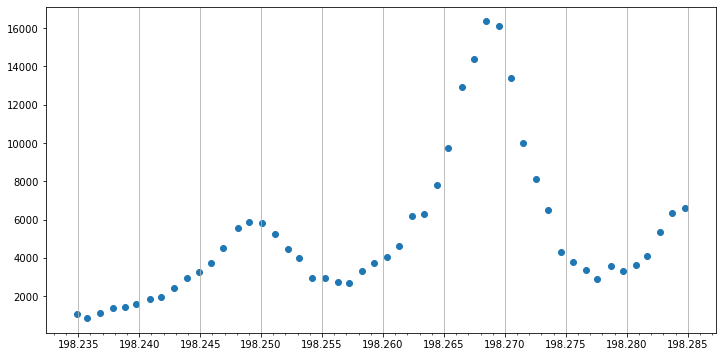

In [138]:
df = CaF_all_freqsVpeaks['1512.028']['5.345A']
f = df['Frequencies (MHz)']
c = df['Counts']
fig, ax = plt.subplots(1, figsize = (12, 6))
ax.scatter(f/1e6, c)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
ax.ticklabel_format(useOffset = False)
ax.grid(axis = 'x', visible = True)
plt.show()

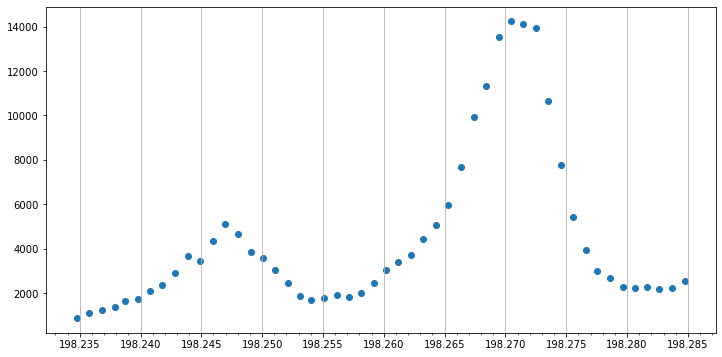

In [ ]:
df = CaF_all_freqsVpeaks['1512.028']['6.491A']
f = df['Frequencies (MHz)']
c = df['Counts']
fig, ax = plt.subplots(1, figsize = (12, 6))
ax.scatter(f/1e6, c)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
ax.ticklabel_format(useOffset = False)
ax.grid(axis = 'x', visible = True)
plt.show()

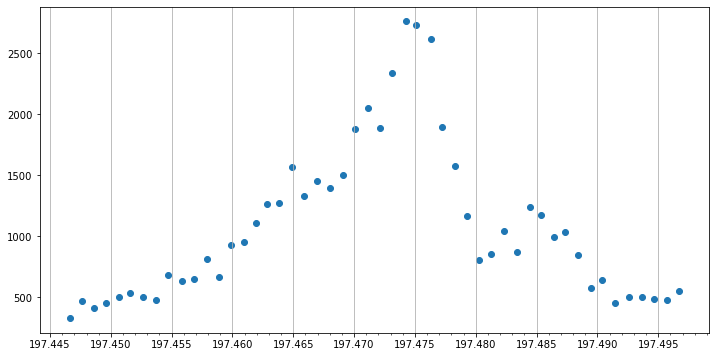

In [133]:
df = CaF_all_freqsVpeaks['1518.061']['7.000A']
f = df['Frequencies (MHz)']
c = df['Counts']
fig, ax = plt.subplots(1, figsize = (12, 6))
ax.scatter(f/1e6, c)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
ax.ticklabel_format(useOffset = False)
ax.grid(axis = 'x', visible = True)
plt.show()

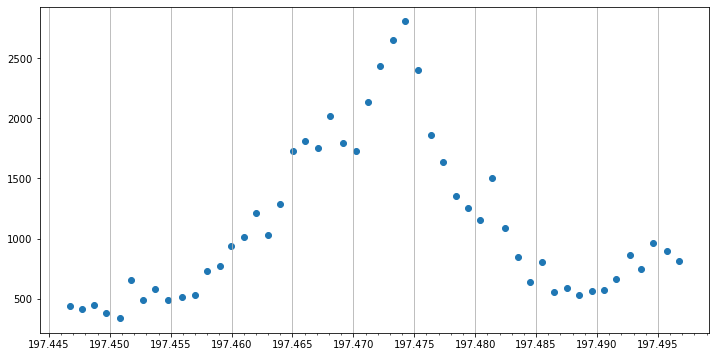

In [139]:
df = CaF_all_freqsVpeaks['1518.061']['5.345A']
f = df['Frequencies (MHz)']
c = df['Counts']
fig, ax = plt.subplots(1, figsize = (12, 6))
ax.scatter(f/1e6, c)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
ax.ticklabel_format(useOffset = False)
ax.grid(axis = 'x', visible = True)
plt.show()

# SiC

In [20]:
# SiC_trn = {
#     'A': [196.088, 1528.767, r'A'],
#     'B': [196.900, 1522.469, r'B'],
#     'C': [197.527, 1517.640, r'C']
#     }

SiC_trn = {
    'B': [196.900, 1522.469, r'B'],
    }

In [44]:
SiC_all_freqsVpeaks, SiC_timeLimit = collect_motor_by_field(sic_0318, 
                                          sites = SiC_trn, 
                                          aom = 0.380, 
                                          num_bins = 150, 
                                          ylim = [0, 4e3])

NameError: name 'SiC_trn' is not defined

Site B at 196.900 THz


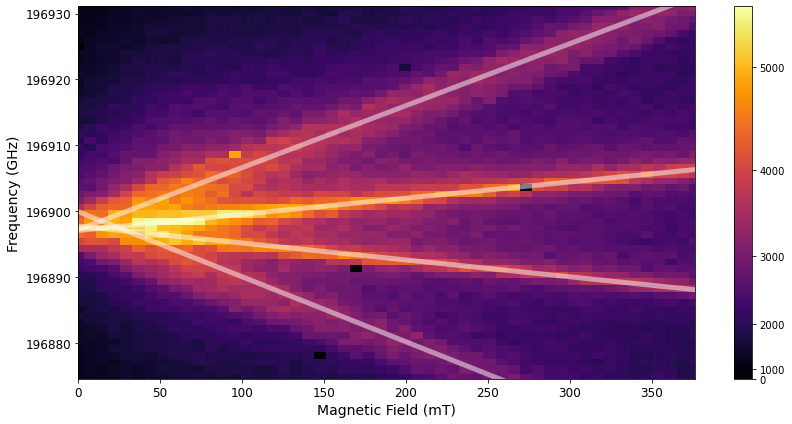

In [47]:
%matplotlib inline
# %matplotlib 
plt.ion()
countLims = [1e8, 1e8, 1e8]

for i, site in enumerate(SiC_trn):
    selected_points.clear()
    
    # ID each site 
    site = SiC_trn[f'{site}']
    wavelength = site[1]
    siteData = SiC_all_freqsVpeaks[f'{wavelength:.3f}']
    print(f'Site {site[2]} at {site[0]:.3f} THz')
    
    # Process to extract data
    counts_matrix, freqs_matrix, currents, freqs = process_colourmap(siteData)
    fields = currents * mango_cc

    # Filter for outliers
    counts_matrix[counts_matrix > countLims[i]] = 0
    
    # Plot Zeeman spectrum
    plt.figure(figsize = (12, 6))
    plt.pcolormesh(fields, freqs/1e3, counts_matrix, cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.6))
    plt.xlabel('Magnetic Field (mT)', fontsize = 14)
    plt.ylabel('Frequency (GHz)', fontsize = 14)
    plt.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
    plt.tick_params(axis = 'both', labelsize = 12) 
    plt.colorbar()

    # Plot fitted g
    x = np.array([0, 400])
    for key in fits_B:
        plt.plot(x, x * key[0] + key[1],
                 color = 'white', linewidth = 5, alpha = 0.5, 
                 label = f'{key[0]*1e3:3f} GHz/T')  

    plt.xlim([min(fields), max(fields)])
    plt.ylim([min(freqs/1e3), max(freqs/1e3)])
    # plt.legend(loc = 'upper left')
    plt.tight_layout()
    plt.show()

    # # Find and save peaks - iterate for each line
    # find_zeeman_peaks_with_click(counts_matrix, freqs_matrix, fields, desc = f'sic_{site[0]:.3f}_THz')

### Quench Test

In [11]:
SiC_trn_C = {
    'C': [197.527, 1517.640, r'C']
    }

In [12]:
SiC_all_freqsVpeaks_C, SiC_timeLimit_C = collect_motor_by_field(sic_0326, 
                                          sites = SiC_trn_C, 
                                          aom = 0.380, 
                                          num_bins = 150, 
                                          ylim = [0, 4e3])

Site C at 197.527 THz


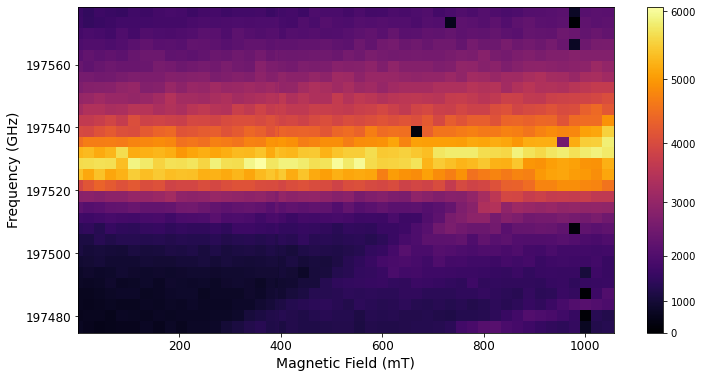

In [48]:
%matplotlib inline
# %matplotlib
plt.ion()
selected_points.clear()
countLims_C = [1e4]
mango_cc = 24.6 # mT/A

for i, site in enumerate(SiC_trn_C):
    # ID each site 
    site = SiC_trn_C[f'{site}']
    wavelength = site[1]
    siteData_C = SiC_all_freqsVpeaks_C[f'{wavelength:.3f}']
    # del siteData_C['43.37879641A'] # remove quench
    print(f'Site {site[2]} at {site[0]:.3f} THz')
    
    # Process to extract data
    counts_matrix, freqs_matrix, currents, freqs = process_colourmap(siteData_C)
    fields = currents * mango_cc

    # Filter for outliers
    counts_matrix[counts_matrix > countLims_C[i]] = 0
    
    # Plot Zeeman spectrum
    plt.figure(figsize = (12, 6))
    cm = plt.pcolormesh(fields[0: -1], freqs/1e3, counts_matrix[:, 0:-1], cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.3))
    # cmap candidates: terrain, turbo, viridis, inferno, 
    # cm.set_clim(0, 8e3)
    plt.xlabel('Magnetic Field (mT)', fontsize = 14)
    plt.ylabel('Frequency (GHz)', fontsize = 14)
    plt.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
    plt.tick_params(axis = 'both', labelsize = 12) 
    plt.colorbar()
    
    # # Find and save peaks - iterate for each line
    # find_zeeman_peaks_with_click(counts_matrix, freqs_matrix, fields, desc = f'sic_{site[0]:.3f}_THz')

# Fitting g-tensors
Used processed matrix of counts and slice into columns for peak picking

### CaF

In [14]:
caf_A_Z1_Y2 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\caf\197.913\*'))
caf_A_Z1_Y1 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\caf\197.050\*'))

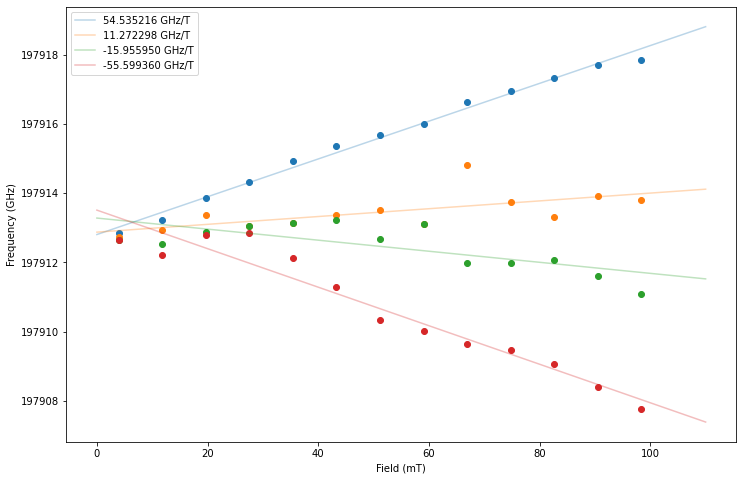

In [15]:
%matplotlib inline
plt.figure(figsize = (12, 8))
fits_caf_Z1_Y2 = []

for i, file in enumerate(caf_A_Z1_Y2):
    if file.lower().endswith('.csv'):
        data = pd.read_csv(file)
        freqs = np.array(data['Frequency (GHz)']/1e3) # converts to GHz
        fields = np.array(data['B Field (mT)'])
        plt.scatter(fields, freqs)
        fits = scs.linregress(fields, freqs)
        x = np.array([0, 110])
        plt.plot(x, x * fits.slope + fits.intercept,
                 alpha = 0.3, 
                 label = f'{fits.slope*1e3:3f} GHz/T')   
        fits_caf_Z1_Y2.append(fits) 

plt.xlabel('Field (mT)')
plt.ylabel('Frequency (GHz)')
plt.ticklabel_format(useOffset = False)
plt.legend()
plt.show()   

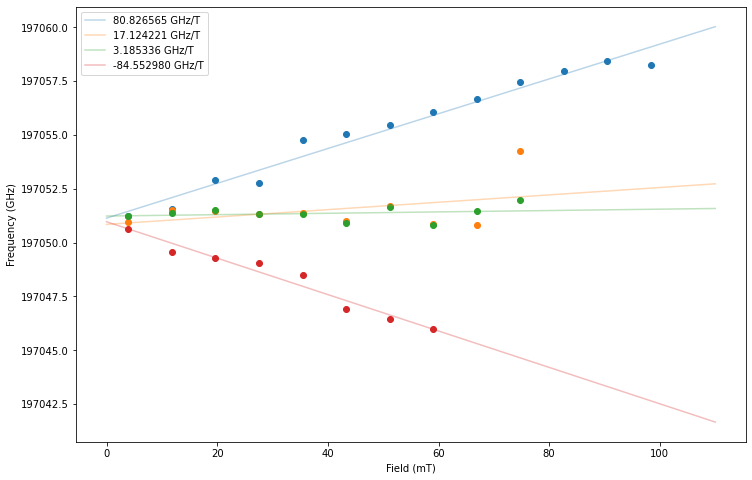

In [102]:
%matplotlib inline
plt.figure(figsize = (12, 8))
fits_caf_Z1_Y1 = []

for i, file in enumerate(caf_A_Z1_Y1):
    if file.lower().endswith('.csv'):
        data = pd.read_csv(file)
        freqs = np.array(data['Frequency (GHz)']/1e3) # converts to GHz
        fields = np.array(data['B Field (mT)'])
        plt.scatter(fields, freqs)
        fits = scs.linregress(fields, freqs)
        x = np.array([0, 110])
        plt.plot(x, x * fits.slope + fits.intercept,
                 alpha = 0.3, 
                 label = f'{fits.slope*1e3:3f} GHz/T')   
        fits_caf_Z1_Y1.append(fits) 

plt.xlabel('Field (mT)')
plt.ylabel('Frequency (GHz)')
plt.ticklabel_format(useOffset = False)
plt.legend()
plt.show() 

### SiC

In [52]:
sic_A = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\196.088\*'))
sic_B = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\196.900\*'))
sic_C = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\197.527\*'))

# Mask for each site
lim_A = np.array([196.020, 196.120])*1e3
lim_B = np.array([196.860, 196.940])*1e3
lim_C = np.array([197.510, 197.550])*1e3

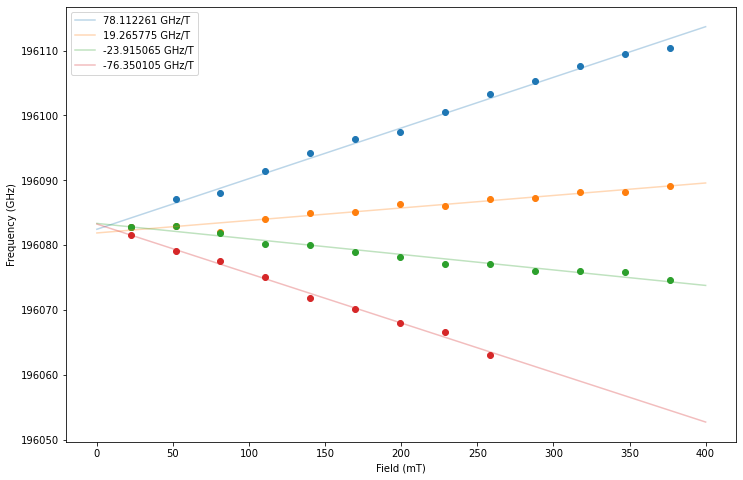

In [53]:
%matplotlib inline
plt.figure(figsize = (12, 8))
fits_A = []

for i, file in enumerate(sic_A):
    if file.lower().endswith('.csv'):
        data = pd.read_csv(file)
        freqs = np.array(data['Frequency (GHz)']/1e3) # converts to GHz
        fields = np.array(data['B Field (mT)'])
        # mask_A = (freqs > lim_A[0]) & (freqs < lim_A[1])
        # fields_A = fields[mask_A]
        # freqs_A = freqs[mask_A]
        plt.scatter(fields, freqs)
        fits = scs.linregress(fields, freqs)
        x = np.array([0, 400])
        plt.plot(x, x * fits.slope + fits.intercept,
                 alpha = 0.3, 
                 label = f'{fits.slope*1e3:3f} GHz/T')   
        fits_A.append(fits) 

plt.xlabel('Field (mT)')
plt.ylabel('Frequency (GHz)')
plt.ticklabel_format(useOffset = False)
plt.legend()
plt.show()   

In [55]:
fits_B

[LinregressResult(slope=0.094133689680043, intercept=196897.1942718766, rvalue=0.9980815317280806, pvalue=1.207022622141331e-14, stderr=0.0017606240619081428, intercept_stderr=0.40111550060617096),
 LinregressResult(slope=0.024586716397399434, intercept=196897.070348492, rvalue=0.9954485441309774, pvalue=1.3903113869797886e-12, stderr=0.0007097098096830309, intercept_stderr=0.16169017097698377),
 LinregressResult(slope=-0.025681366601055345, intercept=196897.74842786268, rvalue=-0.9938378795953094, pvalue=7.336124751792503e-12, stderr=0.000863607198155778, intercept_stderr=0.19675195921150637),
 LinregressResult(slope=-0.09874045551204229, intercept=196899.93861389213, rvalue=-0.9953625890224669, pvalue=2.226085849595014e-08, stderr=0.0036067288877800973, intercept_stderr=0.5756229068105184)]

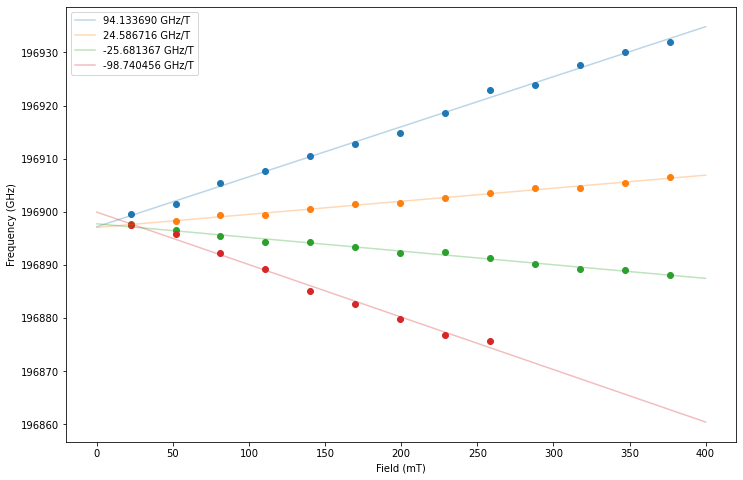

In [54]:
%matplotlib inline
plt.figure(figsize = (12, 8))
fits_B = []
for i, file in enumerate(sic_B):
    if file.lower().endswith('.csv'):
        data = pd.read_csv(file)
        freqs = np.array(data['Frequency (GHz)']/1e3) # converts to GHz
        fields = np.array(data['B Field (mT)'])
        plt.scatter(fields, freqs)
        fits = scs.linregress(fields, freqs) # fitted wrt. (GHz, mT)  
        x = np.array([0, 400])
        plt.plot(x, x * fits.slope + fits.intercept,
                 alpha = 0.3, 
                 label = f'{fits.slope*1e3:3f} GHz/T')    
    fits_B.append(fits)

plt.xlabel('Field (mT)')
plt.ylabel('Frequency (GHz)')
plt.ticklabel_format(useOffset = False)
plt.legend()
plt.show() 

ValueError: Inputs must not be empty.

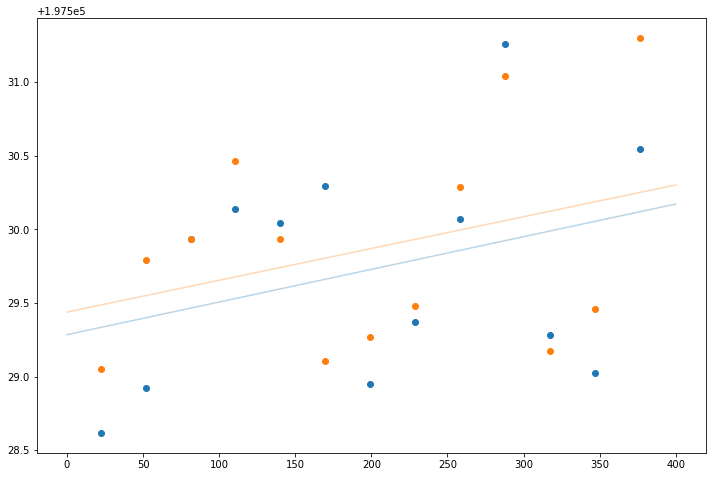

In [ ]:
%matplotlib inline
plt.figure(figsize = (12, 8))

for i, file in enumerate(sic_C):
    if file.lower().endswith('.csv'):
        data = pd.read_csv(file)
        freqs = np.array(data['Frequency (GHz)']/1e3) # converts to GHz
        fields = np.array(data['B Field (mT)'])
        plt.scatter(fields, freqs)   
        fits = scs.linregress(fields, freqs) 
        x = np.array([0, 400])
        plt.plot(x, x * fits.slope + fits.intercept,
                 alpha = 0.3, 
                 label = f'{fits.slope*1e3:3f} GHz/T') 

plt.xlabel('Field (mT)')
plt.ylabel('Frequency (GHz)')
plt.ticklabel_format(useOffset = False)  
plt.legend()
plt.show()  